In [1]:
# LOCALIZED BLUR DETECTION - NIH-CXR14 DATASET
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

import torch
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of visible GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

1
NVIDIA GeForce RTX 3090
CUDA available: True
Number of visible GPUs: 1
Device 0: NVIDIA GeForce RTX 3090


In [2]:
import cv2
import numpy as np
import random
import torch
import gc
import os
import pandas as pd
import hashlib
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import json
import time
from datetime import datetime
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, classification_report
)

import matplotlib.pyplot as plt

2026-03-06 10:22:19.333886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# NIH-CXR14 paths
IMG_DIR    = Path("/data0/NIH-CXR14/images")
RAW_CSV    = Path("/data0/NIH-CXR14/Data_Entry_2017_v2020.csv")
WORK_DIR   = Path("/home/jupyter-yin10/Image_Analysis")
OUTPUT_DIR = WORK_DIR / "NIH_Localized_Blur_4x4"

# Train/test split will be created
TRAIN_CSV  = OUTPUT_DIR / "train.csv"
TEST_CSV   = OUTPUT_DIR / "test.csv"

# --- Localised blur parameters (IDENTICAL to Emory) ---
PATCH_SIZES    = [4]
NUM_PATCHES    = 1          
BLUR_KSIZE     = 21         
BLUR_SIGMA     = 0          

# HuggingFace token for DINOv3 (GATED MODEL)
HF_TOKEN = "hf_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"  

# Anatomical placement (IDENTICAL to Emory)
PLACEMENT_MARGIN = 0.20     # 20% margin from each edge

BATCH_SIZE = 16  # Adjusted for RTX 3090

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# Cell 4: Train/Test Split Management
# ============================================================================
# CREATE OR COPY TRAIN/TEST SPLIT
# ============================================================================

import shutil

# Source: 8×8 directory (where original split lives)
source_dir = WORK_DIR / "NIH_Localized_Blur_8x8"

# Check if we're running 4×4 and 8×8 split exists
if OUTPUT_DIR.name == "NIH_Localized_Blur_4x4":
    source_train = source_dir / "train.csv"
    source_test = source_dir / "test.csv"
    
    if source_train.exists() and source_test.exists():
        print("Copying train/test split from 8×8 to ensure identical splits...")
        
        # Create 4×4 directory if it doesn't exist
        OUTPUT_DIR.mkdir(exist_ok=True)
        
        # Copy train.csv
        shutil.copy(source_train, TRAIN_CSV)
        print(f"✓ Copied: {source_train} → {TRAIN_CSV}")
        
        # Copy test.csv
        shutil.copy(source_test, TEST_CSV)
        print(f"✓ Copied: {source_test} → {TEST_CSV}")
        
        # Verify
        df_train = pd.read_csv(TRAIN_CSV)
        df_test = pd.read_csv(TEST_CSV)
        print(f"\nTrain set: {len(df_train)} images")
        print(f"Test set:  {len(df_test)} images")
        print("✅ Using IDENTICAL split as 8×8!")
    else:
        raise FileNotFoundError(
            f"8×8 split files not found in {source_dir}\n"
            "Please run 8×8 experiment first to create the split."
        )

elif OUTPUT_DIR.name == "NIH_Localized_Blur_8x8":
    # For 8×8: check if split already exists, otherwise create it
    if TRAIN_CSV.exists() and TEST_CSV.exists():
        print("Train/test split already exists for 8×8. Using existing split...")
        df_train = pd.read_csv(TRAIN_CSV)
        df_test = pd.read_csv(TEST_CSV)
        print(f"Train set: {len(df_train)} images")
        print(f"Test set:  {len(df_test)} images")
        print("✅ Using existing 8×8 split")
    else:
        print("Creating NEW train/test split for 8×8...")
        df_all = pd.read_csv(RAW_CSV)

        # Random 80/20 split
        np.random.seed(42)
        train_indices = np.random.choice(len(df_all), size=int(len(df_all) * 0.8), replace=False)
        test_indices = np.array([i for i in range(len(df_all)) if i not in train_indices])

        df_train = df_all.iloc[train_indices].reset_index(drop=True)
        df_test  = df_all.iloc[test_indices].reset_index(drop=True)

        # Save to CSV
        df_train.to_csv(TRAIN_CSV, index=False)
        df_test.to_csv(TEST_CSV, index=False)

        print(f"Train set: {len(df_train)} images")
        print(f"Test set:  {len(df_test)} images")
        print("✓ Created new split for 8×8")

else:
    raise ValueError(f"Unknown output directory: {OUTPUT_DIR.name}")

Copying train/test split from 8×8 to ensure identical splits...
✓ Copied: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_8x8/train.csv → /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_4x4/train.csv
✓ Copied: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_8x8/test.csv → /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_4x4/test.csv

Train set: 89696 images
Test set:  22424 images
✅ Using IDENTICAL split as 8×8!


In [5]:
# ============================================================================
# CLASSES
# ============================================================================

class ImagePreprocessor:
    """Load and validate NIH images (already 1024×1024, no resizing needed)."""

    def __init__(self, target_size=(1024, 1024)):
        self.target_size = target_size

    def analyze_image_color_distribution(self, image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image

        hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
        hist_for_peaks = hist.copy()
        hist_for_peaks[:21]  = 0
        hist_for_peaks[235:] = 0

        mode_value = np.argmax(hist_for_peaks) if np.sum(hist_for_peaks) > 0 else 128
        if mode_value <= 20 or mode_value >= 235:
            mode_value = 128

        min_noise_color = max(20,  mode_value - 20)
        max_noise_color = min(235, mode_value + 20)

        return mode_value, (min_noise_color, max_noise_color), hist

    def load_and_validate(self, image_path):
        """Load image and validate it's 1024×1024 (no resizing)."""
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f"Cannot load: {image_path}")

        h, w = image.shape[:2]
        
        # Validate size
        if (h, w) != self.target_size:
            # If not 1024×1024, pad to 1024 (just in case)
            max_dim = max(h, w, 1024)
            pad_h, pad_w = max_dim - h, max_dim - w
            top, bottom  = pad_h // 2, pad_h - pad_h // 2
            left, right  = pad_w // 2, pad_w - pad_w // 2

            if len(image.shape) == 3:
                padded = cv2.copyMakeBorder(image, top, bottom, left, right,
                                            cv2.BORDER_CONSTANT, value=[0, 0, 0])
            else:
                padded = cv2.copyMakeBorder(image, top, bottom, left, right,
                                            cv2.BORDER_CONSTANT, value=0)
            image = padded

        mode_value, noise_range, hist = self.analyze_image_color_distribution(image)
        color_analysis = {'mode_value': mode_value, 'noise_range': noise_range, 'histogram': hist}

        return image, color_analysis


class LocalizedBlurInjector:
    """
    IDENTICAL to Emory code.
    Injects clinically-motivated localised Gaussian blur patches.
    """

    def __init__(self, seed=42):
        self.seed = seed

    def _get_deterministic_seed(self, image_path):
        filename    = os.path.basename(str(image_path))
        seed_string = f"{self.seed}_{filename}"
        hash_object = hashlib.sha256(seed_string.encode())
        return int(hash_object.hexdigest()[:8], 16)

    def _sample_patch_origin(self, rng, image_h, image_w, patch_size, margin=PLACEMENT_MARGIN):
        """
        Sample a top-left (y, x) coordinate such that the patch:
        - stays fully within the image
        - is placed in the anatomical zone (central 1-2*margin fraction)
        """
        y_min = int(image_h * margin)
        y_max = int(image_h * (1 - margin)) - patch_size
        x_min = int(image_w * margin)
        x_max = int(image_w * (1 - margin)) - patch_size

        # Clamp so max >= min (safety for very small images)
        y_max = max(y_min + 1, y_max)
        x_max = max(x_min + 1, x_max)

        y = rng.integers(y_min, y_max)
        x = rng.integers(x_min, x_max)
        return int(y), int(x)

    def add_localized_blur(
        self,
        image,
        patch_sizes=PATCH_SIZES,
        num_patches=NUM_PATCHES,
        blur_ksize=BLUR_KSIZE,
        blur_sigma=BLUR_SIGMA,
        image_path=None
    ):
        """
        Apply localised Gaussian blur to `num_patches` small regions.
        IDENTICAL to Emory code.
        """
        seed = self._get_deterministic_seed(image_path) if image_path else self.seed
        rng  = np.random.default_rng(seed)

        noisy  = image.copy()
        h, w   = image.shape[:2]

        # Pre-compute the globally blurred version once — extract patches from it
        blurred_full = cv2.GaussianBlur(image, (blur_ksize, blur_ksize), blur_sigma)

        patch_log = []  # [(y, x, size)] for reproducibility logging

        for _ in range(num_patches):
            ps  = int(rng.choice(patch_sizes))
            y, x = self._sample_patch_origin(rng, h, w, ps)

            # Replace the patch in noisy with the blurred version
            noisy[y:y+ps, x:x+ps] = blurred_full[y:y+ps, x:x+ps]
            patch_log.append({'y': y, 'x': x, 'size': ps})

        noisy = np.clip(noisy, 20, 235).astype(np.uint8)

        meta = {
            'patch_sizes_used': [p['size'] for p in patch_log],
            'patch_locations':   patch_log
        }
        return noisy, meta


class EmbeddingExtractor:
    """Extract embeddings from ONE model at a time."""

    def __init__(self, model_name='raddino', hf_token=None):
        """
        model_name: 'raddino' or 'dinov3'
        """
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.hf_token = hf_token
        self.model_name = model_name
        print(f"Using device: {self.device}")
        print(f"Loading {model_name.upper()} model...")
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        if model_name == 'raddino':
            self.load_raddino_model()
        elif model_name == 'dinov3':
            self.load_dinov3_model()
        else:
            raise ValueError(f"Unknown model: {model_name}")

    def load_raddino_model(self):
        try:
            self.processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
            self.model = AutoModel.from_pretrained("microsoft/rad-dino").to(self.device)
            self.model.eval()
            print("RAD-DINO model loaded successfully")
        except Exception as e:
            print(f"Error loading RAD-DINO model: {e}")
            raise

    def load_dinov3_model(self):
        try:
            self.processor = AutoImageProcessor.from_pretrained(
                "facebook/dinov3-vit7b16-pretrain-lvd1689m",
                token=self.hf_token
            )
            self.model = AutoModel.from_pretrained(
                "facebook/dinov3-vit7b16-pretrain-lvd1689m",
                token=self.hf_token,
                torch_dtype=torch.float16
            ).to(self.device)
            self.model.eval()
            print("DINOv3 model loaded successfully")
        except Exception as e:
            print(f"Error loading DINOv3 model: {e}")
            raise

    def _to_pil(self, image):
        if image.ndim == 3:
            return Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        else:
            return Image.fromarray(image).convert("RGB")

    def extract_batch(self, images):
        """Extract embeddings from current model only."""
        pil_list = [self._to_pil(im) for im in images]
        
        with torch.no_grad():
            inputs = self.processor(pil_list, return_tensors="pt").to(self.device)
            outputs = self.model(**inputs)
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                embeddings = outputs.pooler_output
            else:
                embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings = embeddings.detach().cpu().numpy()
        
        return embeddings


class LinearProbingAnalyzer:
    """IDENTICAL to Emory code."""

    def __init__(self, n_bootstrap=1000, confidence_level=0.95):
        self.results          = {}
        self.n_bootstrap      = n_bootstrap
        self.confidence_level = confidence_level

    def load_embeddings(self, parquet_path, embedding_col):
        df = pd.read_parquet(parquet_path)
        valid_mask = df[embedding_col].notna()
        df_valid   = df[valid_mask].copy()

        embeddings, labels = [], []
        for _, row in df_valid.iterrows():
            emb = row[embedding_col]
            if isinstance(emb, str):
                import ast
                emb = ast.literal_eval(emb)
            if isinstance(emb, list):
                emb = np.array(emb)
            embeddings.append(emb)
            labels.append(row['noise'])

        X = np.vstack(embeddings)
        y = np.array(labels).astype(int)
        return X, y

    def _best_f1_threshold(self, y_true, y_proba):
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
        f1s = (2 * precisions[1:] * recalls[1:]) / (precisions[1:] + recalls[1:] + 1e-12)
        if len(f1s) == 0:
            return 0.5, 0.0
        idx = np.argmax(f1s)
        return float(thresholds[idx]), float(f1s[idx])

    def _bootstrap_metrics(self, y_test, y_test_proba, threshold):
        n_samples  = len(y_test)
        auc_scores = []
        f1_scores  = []

        for _ in range(self.n_bootstrap):
            indices       = np.random.choice(n_samples, size=n_samples, replace=True)
            y_boot        = y_test[indices]
            y_proba_boot  = y_test_proba[indices]

            if len(np.unique(y_boot)) > 1:
                auc_scores.append(roc_auc_score(y_boot, y_proba_boot))

            y_pred_boot = (y_proba_boot >= threshold).astype(int)
            f1_scores.append(f1_score(y_boot, y_pred_boot, zero_division=0))

        alpha  = 1 - self.confidence_level
        auc_ci = np.percentile(auc_scores, [100*alpha/2, 100*(1-alpha/2)]) if auc_scores else [0, 0]
        f1_ci  = np.percentile(f1_scores,  [100*alpha/2, 100*(1-alpha/2)])
        return auc_ci, f1_ci

    def train_and_evaluate(self, model_name, X_train, y_train, X_test, y_test):
        print(f"\nTraining {model_name.upper()}...")

        scaler        = StandardScaler()
        X_train_sc    = scaler.fit_transform(X_train)
        X_test_sc     = scaler.transform(X_test)

        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_train_sc, y_train)

        y_test_proba = model.predict_proba(X_test_sc)[:, 1]
        auc_score    = roc_auc_score(y_test, y_test_proba)
        fpr, tpr, _  = roc_curve(y_test, y_test_proba)

        best_thr, _  = self._best_f1_threshold(y_test, y_test_proba)
        y_pred       = (y_test_proba >= best_thr).astype(int)
        f1           = f1_score(y_test, y_pred)

        print(f"Computing {self.confidence_level*100:.0f}% CI ({self.n_bootstrap} bootstrap samples)...")
        auc_ci, f1_ci = self._bootstrap_metrics(y_test, y_test_proba, best_thr)

        print(f"{model_name.upper()} - AUC: {auc_score:.4f} [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}] "
              f"| F1@{best_thr:.3f}: {f1:.4f} [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")
        print(classification_report(y_test, y_pred, digits=4))

        self.results[model_name] = {
            'auc': auc_score, 'auc_ci': auc_ci,
            'f1':  f1,        'f1_ci':  f1_ci,
            'threshold': best_thr,
            'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred
        }
        return auc_score, f1

    def plot_roc_curves(self, save_path):
        plt.figure(figsize=(10, 8))
        colors = {'raddino': '#2E86C1', 'dinov3': '#E74C3C'}

        for model_name in ['raddino', 'dinov3']:
            if model_name in self.results:
                r = self.results[model_name]
                auc_ci_str = f"[{r['auc_ci'][0]:.3f}–{r['auc_ci'][1]:.3f}]"
                f1_ci_str  = f"[{r['f1_ci'][0]:.3f}–{r['f1_ci'][1]:.3f}]"
                label = (f'{model_name.upper()} '
                         f'(AUC={r["auc"]:.3f} {auc_ci_str}, '
                         f'F1={r["f1"]:.3f} {f1_ci_str})')
                plt.plot(r['fpr'], r['tpr'],
                         color=colors[model_name], linewidth=2.5, label=label)

        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title(
            f'Localised Blur Detection — ROC Curves\n'
            f'({NUM_PATCHES} patches × {PATCH_SIZES} px | Gaussian k={BLUR_KSIZE})',
            fontsize=14, fontweight='bold'
        )
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Plot saved: {save_path}")


class ProgressTracker:
    """IDENTICAL to Emory code."""

    def __init__(self, output_dir):
        self.output_dir    = output_dir
        self.progress_file = os.path.join(output_dir, "progress.json")
        self.load_progress()

    def load_progress(self):
        if os.path.exists(self.progress_file):
            with open(self.progress_file, 'r') as f:
                self.progress = json.load(f)
        else:
            self.progress = {
                "completed_tasks": [],
                "current_task":    None,
                "last_updated":    None
            }

    def save_progress(self):
        self.progress["last_updated"] = datetime.now().isoformat()
        os.makedirs(self.output_dir, exist_ok=True)
        with open(self.progress_file, 'w') as f:
            json.dump(self.progress, f, indent=2)

    def is_task_completed(self, task_id):
        return task_id in self.progress["completed_tasks"]

    def mark_task_completed(self, task_id):
        if task_id not in self.progress["completed_tasks"]:
            self.progress["completed_tasks"].append(task_id)
        self.save_progress()

    def set_current_task(self, task_id):
        self.progress["current_task"] = task_id
        self.save_progress()


In [6]:
# ============================================================================
# PIPELINE FUNCTIONS
# ============================================================================
def process_dataset_single_model(csv_path, split_name, preprocessor, injector, 
                                  extractor, model_name,
                                  batch_size=BATCH_SIZE, save_intermediate=True,
                                  intermediate_save_frequency=50):
    """Process one split with ONE model only."""
    print(f"\n{'='*70}")
    print(f"PROCESSING {split_name.upper()} SET - {model_name.upper()} MODEL")
    print(f"{'='*70}")

    df = pd.read_csv(csv_path)
    df['full_path'] = df['Image Index'].apply(lambda x: str(IMG_DIR / x))

    results     = []
    num_batches = (len(df) + batch_size - 1) // batch_size

    if save_intermediate:
        intermediate_dir  = os.path.join(OUTPUT_DIR, "intermediate_saves")
        os.makedirs(intermediate_dir, exist_ok=True)
        intermediate_path = os.path.join(
            intermediate_dir, f"localized_blur_{split_name}_{model_name}_intermediate.parquet"
        )

    batch_count = 0
    for batch_idx in tqdm(range(num_batches), desc=f"Processing {split_name} ({model_name})"):
        batch_start_time = time.time()
        start_idx  = batch_idx * batch_size
        end_idx    = min(start_idx + batch_size, len(df))
        batch_df   = df.iloc[start_idx:end_idx]

        clean_images = []
        noisy_images = []
        patch_metas  = []
        valid_rows   = []

        for _, row in batch_df.iterrows():
            img_path = row['full_path']
            if not os.path.exists(img_path):
                continue
            try:
                processed, color_analysis = preprocessor.load_and_validate(img_path)
                clean_images.append(processed)

                noisy, meta = injector.add_localized_blur(
                    processed,
                    patch_sizes=PATCH_SIZES,
                    num_patches=NUM_PATCHES,
                    blur_ksize=BLUR_KSIZE,
                    blur_sigma=BLUR_SIGMA,
                    image_path=img_path
                )
                noisy_images.append(noisy)
                patch_metas.append(meta)
                valid_rows.append(row)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue

        if len(clean_images) == 0:
            continue

        # Extract embeddings from ONE model
        clean_embs = extractor.extract_batch(clean_images)
        noisy_embs = extractor.extract_batch(noisy_images)

        # Store results
        for i, row in enumerate(valid_rows):
            base_record = {
                'Patient_ID':     row.get('Patient ID', ''),
                'ImagePath':      row['Image Index'],
                'Finding_Labels': row.get('Finding Labels', ''),
            }

            # Clean image record
            results.append({
                **base_record,
                'noise':      0,
                'patch_meta': None,
                'embedding':  clean_embs[i].tolist(),
            })

            # Noisy image record
            results.append({
                **base_record,
                'noise':      1,
                'patch_meta': json.dumps(patch_metas[i]),
                'embedding':  noisy_embs[i].tolist(),
            })

        # Memory cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        batch_count += 1
        batch_time   = time.time() - batch_start_time

        if save_intermediate and (
            batch_count % intermediate_save_frequency == 0 or batch_count == num_batches
        ):
            pd.DataFrame(results).to_parquet(intermediate_path, index=False)

        if batch_count % 10 == 0 or batch_count == num_batches:
            print(f"\nBatch {batch_count}/{num_batches}: "
                  f"Time={batch_time:.2f}s, "
                  f"Images/sec={len(clean_images)/batch_time:.2f}")
            if batch_count < num_batches:
                remaining_batches = num_batches - batch_count
                estimated_time    = remaining_batches * batch_time / 60
                print(f"Estimated remaining time: {estimated_time:.1f} minutes")

    # Save final parquet
    results_df  = pd.DataFrame(results)
    output_path = os.path.join(OUTPUT_DIR, f"localized_blur_{split_name}_{model_name}.parquet")
    results_df.to_parquet(output_path, index=False)
    print(f"\nSaved: {output_path}")
    print(f"Total samples: {len(results_df)}")
    return output_path


# ============================================================================
# NEW: Merge embeddings from both models
# ============================================================================
def merge_embeddings(train_raddino_path, train_dinov3_path, 
                     test_raddino_path, test_dinov3_path):
    """Merge RAD-DINO and DINOv3 embeddings into final parquet files."""
    print(f"\n{'='*70}")
    print("MERGING EMBEDDINGS FROM BOTH MODELS")
    print(f"{'='*70}")
    
    for split, rad_path, dino_path in [
        ('train', train_raddino_path, train_dinov3_path),
        ('test', test_raddino_path, test_dinov3_path)
    ]:
        print(f"\nMerging {split} set...")
        
        # Load both
        df_rad = pd.read_parquet(rad_path)
        df_dino = pd.read_parquet(dino_path)
        
        # Verify they match
        assert len(df_rad) == len(df_dino), f"{split}: Length mismatch!"
        assert (df_rad['ImagePath'] == df_dino['ImagePath']).all(), f"{split}: ImagePath mismatch!"
        assert (df_rad['noise'] == df_dino['noise']).all(), f"{split}: noise label mismatch!"
        
        # Merge embeddings
        df_merged = df_rad.copy()
        df_merged['raddino_embedding'] = df_rad['embedding']
        df_merged['dinov3_embedding'] = df_dino['embedding']
        df_merged = df_merged.drop('embedding', axis=1)
        
        # Save
        output_path = os.path.join(OUTPUT_DIR, f"localized_blur_{split}.parquet")
        df_merged.to_parquet(output_path, index=False)
        print(f"✓ Saved: {output_path}")
        print(f"  Samples: {len(df_merged)}")
    
    print("\n✅ Embeddings merged successfully!")


# ============================================================================
# KEEP UNCHANGED: Linear probing function
# ============================================================================
def run_linear_probing(train_path, test_path, n_bootstrap=1000, confidence_level=0.95):
    """IDENTICAL to Emory code."""
    print(f"\n{'='*70}")
    print("LINEAR PROBING ANALYSIS WITH CONFIDENCE INTERVALS")
    print(f"{'='*70}")
    print(f"Bootstrap samples: {n_bootstrap}, Confidence level: {confidence_level*100:.0f}%")

    analyzer = LinearProbingAnalyzer(n_bootstrap=n_bootstrap, confidence_level=confidence_level)

    print("\nLoading embeddings...")
    X_train_rad,  y_train_rad  = analyzer.load_embeddings(train_path, 'raddino_embedding')
    X_test_rad,   y_test_rad   = analyzer.load_embeddings(test_path,  'raddino_embedding')
    X_train_dino, y_train_dino = analyzer.load_embeddings(train_path, 'dinov3_embedding')
    X_test_dino,  y_test_dino  = analyzer.load_embeddings(test_path,  'dinov3_embedding')

    print(f"Train samples: {len(X_train_rad)}, Test samples: {len(X_test_rad)}")

    analyzer.train_and_evaluate('raddino', X_train_rad,  y_train_rad,  X_test_rad,  y_test_rad)
    analyzer.train_and_evaluate('dinov3',  X_train_dino, y_train_dino, X_test_dino, y_test_dino)

    roc_path = os.path.join(OUTPUT_DIR, 'localized_blur_roc_curves.png')
    analyzer.plot_roc_curves(roc_path)

    print(f"\n{'='*70}")
    print("RESULTS SUMMARY")
    print(f"{'='*70}")
    print(f"{'Model':<10s} | {'AUC':<32s} | {'F1':<32s} | Threshold")
    print(f"{'-'*80}")
    for model, metrics in analyzer.results.items():
        auc_str = f"{metrics['auc']:.4f} [{metrics['auc_ci'][0]:.4f}–{metrics['auc_ci'][1]:.4f}]"
        f1_str  = f"{metrics['f1']:.4f}  [{metrics['f1_ci'][0]:.4f}–{metrics['f1_ci'][1]:.4f}]"
        print(f"{model.upper():<10s} | {auc_str:<32s} | {f1_str:<32s} | {metrics['threshold']:.3f}")
    print(f"{'='*70}")

    return analyzer

In [7]:
# VISUALISE PATCH INJECTION
def visualise_localized_blur(image_path, preprocessor, injector, save_path=None):
    """Side-by-side comparison: original vs localised-blur image."""
    processed, _  = preprocessor.load_and_validate(image_path)
    noisy, meta   = injector.add_localized_blur(
        processed, patch_sizes=PATCH_SIZES, num_patches=NUM_PATCHES,
        blur_ksize=BLUR_KSIZE, blur_sigma=BLUR_SIGMA, image_path=image_path
    )

    # Draw patch bounding boxes
    noisy_annotated = noisy.copy()
    for p in meta['patch_locations']:
        y, x, ps = p['y'], p['x'], p['size']
        colour = (0, 0, 255) if ps == 16 else (0, 255, 0)  # red=16px, green=64px
        cv2.rectangle(noisy_annotated, (x, y), (x+ps, y+ps), colour, 2)

    # Convert BGR → RGB for matplotlib
    orig_rgb  = cv2.cvtColor(processed,      cv2.COLOR_BGR2RGB) if len(processed.shape) == 3 else processed
    noisy_rgb = cv2.cvtColor(noisy_annotated, cv2.COLOR_BGR2RGB) if len(noisy_annotated.shape) == 3 else noisy_annotated

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(orig_rgb,  cmap='gray')
    axes[0].set_title('Original (clean)', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(noisy_rgb, cmap='gray')
    axes[1].set_title(
        f'Localised Blur  |  Patches: {PATCH_SIZES}px',
        fontsize=12
    )
    axes[1].axis('off')

    plt.suptitle(
        f'Patch sizes: {meta["patch_sizes_used"]}   |   '
        f'Gaussian kernel: {BLUR_KSIZE}×{BLUR_KSIZE}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved visualisation: {save_path}")
    plt.show()


Saved visualisation: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_4x4/sample_patch_visualisation.png


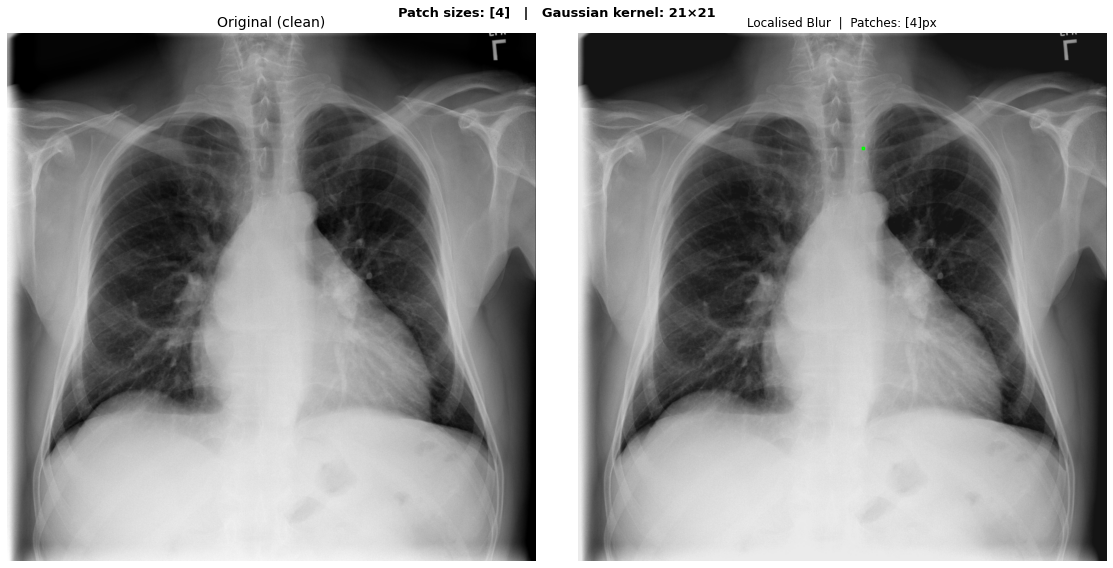

In [8]:
sample_img = IMG_DIR / "00000001_000.png"
prep  = ImagePreprocessor()
inj   = LocalizedBlurInjector(seed=42)
visualise_localized_blur(sample_img, prep, inj,
save_path=OUTPUT_DIR / 'sample_patch_visualisation.png')

In [ ]:
# Main
if __name__ == "__main__":
    print(f"\n{'='*70}")
    print("LOCALISED BLUR NOISE — NIH-CXR14 DATASET (TWO-PASS)")
    print(f"{'='*70}")
    print(f"Patch sizes : {PATCH_SIZES} px ")
    print(f"Num patches : {NUM_PATCHES} per image")
    print(f"Gaussian k  : {BLUR_KSIZE}×{BLUR_KSIZE}  sigma={BLUR_SIGMA}")
    print(f"Placement   : central {int((1-2*PLACEMENT_MARGIN)*100)}% of image")
    print(f"Batch size  : {BATCH_SIZE}")
    print(f"Output      : {OUTPUT_DIR}")
    print(f"\n🔄 TWO-PASS MODE: DINOv3 first, then RAD-DINO")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    tracker      = ProgressTracker(OUTPUT_DIR)
    preprocessor = ImagePreprocessor()
    injector     = LocalizedBlurInjector(seed=42)

    # ============================================================
    # PASS 1: DINOV3
    # ============================================================
    print(f"\n{'='*70}")
    print("PASS 1: DINOV3 MODEL")
    print(f"{'='*70}")
    
    extractor_dinov3 = EmbeddingExtractor(model_name='dinov3', hf_token=HF_TOKEN)
    
    train_task_dino = "train_dinov3"
    if not tracker.is_task_completed(train_task_dino):
        tracker.set_current_task(train_task_dino)
        train_dino_path = process_dataset_single_model(
            TRAIN_CSV, "train", preprocessor, injector, extractor_dinov3, "dinov3",
            batch_size=BATCH_SIZE, save_intermediate=True,
            intermediate_save_frequency=50
        )
        tracker.mark_task_completed(train_task_dino)
    else:
        print("\nTrain DINOv3 already processed. Skipping...")
        train_dino_path = os.path.join(OUTPUT_DIR, "localized_blur_train_dinov3.parquet")

    test_task_dino = "test_dinov3"
    if not tracker.is_task_completed(test_task_dino):
        tracker.set_current_task(test_task_dino)
        test_dino_path = process_dataset_single_model(
            TEST_CSV, "test", preprocessor, injector, extractor_dinov3, "dinov3",
            batch_size=BATCH_SIZE, save_intermediate=True,
            intermediate_save_frequency=50
        )
        tracker.mark_task_completed(test_task_dino)
    else:
        print("\nTest DINOv3 already processed. Skipping...")
        test_dino_path = os.path.join(OUTPUT_DIR, "localized_blur_test_dinov3.parquet")
    
    # Unload DINOv3
    del extractor_dinov3
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    print("\n✅ DINOv3 pass complete and unloaded")

    # ============================================================
    # PASS 2: RAD-DINO
    # ============================================================
    print(f"\n{'='*70}")
    print("PASS 2: RAD-DINO MODEL")
    print(f"{'='*70}")
    
    extractor_raddino = EmbeddingExtractor(model_name='raddino', hf_token=HF_TOKEN)
    
    train_task_rad = "train_raddino"
    if not tracker.is_task_completed(train_task_rad):
        tracker.set_current_task(train_task_rad)
        train_rad_path = process_dataset_single_model(
            TRAIN_CSV, "train", preprocessor, injector, extractor_raddino, "raddino",
            batch_size=BATCH_SIZE, save_intermediate=True,
            intermediate_save_frequency=50
        )
        tracker.mark_task_completed(train_task_rad)
    else:
        print("\nTrain RAD-DINO already processed. Skipping...")
        train_rad_path = os.path.join(OUTPUT_DIR, "localized_blur_train_raddino.parquet")

    test_task_rad = "test_raddino"
    if not tracker.is_task_completed(test_task_rad):
        tracker.set_current_task(test_task_rad)
        test_rad_path = process_dataset_single_model(
            TEST_CSV, "test", preprocessor, injector, extractor_raddino, "raddino",
            batch_size=BATCH_SIZE, save_intermediate=True,
            intermediate_save_frequency=50
        )
        tracker.mark_task_completed(test_task_rad)
    else:
        print("\nTest RAD-DINO already processed. Skipping...")
        test_rad_path = os.path.join(OUTPUT_DIR, "localized_blur_test_raddino.parquet")
    
    del extractor_raddino
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    print("\n✅ RAD-DINO pass complete and unloaded")

    # ============================================================
    # MERGE EMBEDDINGS
    # ============================================================
    merge_task = "merge_embeddings"
    if not tracker.is_task_completed(merge_task):
        tracker.set_current_task(merge_task)
        merge_embeddings(train_rad_path, train_dino_path, test_rad_path, test_dino_path)
        tracker.mark_task_completed(merge_task)
    else:
        print("\nEmbeddings already merged. Skipping...")

    # ============================================================
    # LINEAR PROBING (unchanged from original)
    # ============================================================
    train_path = os.path.join(OUTPUT_DIR, "localized_blur_train.parquet")
    test_path = os.path.join(OUTPUT_DIR, "localized_blur_test.parquet")
    
    lp_task = "linear_probing"
    if not tracker.is_task_completed(lp_task):
        tracker.set_current_task(lp_task)
        analyzer = run_linear_probing(
            train_path, test_path,
            n_bootstrap=1000,
            confidence_level=0.95
        )
        tracker.mark_task_completed(lp_task)
    else:
        print("\nLinear probing already completed. Skipping...")

    print(f"\n✅ COMPLETE! Results in: {OUTPUT_DIR}")


LOCALISED BLUR NOISE — NIH-CXR14 DATASET (TWO-PASS)
Patch sizes : [4] px 
Num patches : 1 per image
Gaussian k  : 21×21  sigma=0
Placement   : central 60% of image
Batch size  : 16
Output      : /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_4x4

🔄 TWO-PASS MODE: DINOv3 first, then RAD-DINO

PASS 1: DINOV3 MODEL
Using device: cuda
Loading DINOV3 model...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

DINOv3 model loaded successfully

PROCESSING TRAIN SET - DINOV3 MODEL


Processing train (dinov3):   0%|          | 10/5606 [00:23<3:35:47,  2.31s/it]

...


Batch 1360/1402: Time=3.50s, Images/sec=4.57
Estimated remaining time: 2.4 minutes


Processing test (raddino):  98%|█████████▊| 1370/1402 [1:16:22<01:52,  3.51s/it]


Batch 1370/1402: Time=3.50s, Images/sec=4.57
Estimated remaining time: 1.9 minutes


Processing test (raddino):  98%|█████████▊| 1378/1402 [1:16:50<01:22,  3.45s/it]

✓ Saved: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_4x4/localized_blur_train.parquet
  Samples: 179392

Merging test set...
✓ Saved: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_4x4/localized_blur_test.parquet
  Samples: 44848

✅ Embeddings merged successfully!

LINEAR PROBING ANALYSIS WITH CONFIDENCE INTERVALS
Bootstrap samples: 1000, Confidence level: 95%

Loading embeddings...



LINEAR PROBING ANALYSIS WITH CONFIDENCE INTERVALS
Bootstrap samples: 1000, Confidence level: 95%

Loading embeddings...
Train samples: 179392, Test samples: 44848

Training RADDINO...
Computing 95% CI (1000 bootstrap samples)...
RADDINO - AUC: 0.6640 [0.6590, 0.6691] | F1@0.350: 0.6755 [0.6708, 0.6800]
              precision    recall  f1-score   support

           0     0.7043    0.2209    0.3363     22424
           1     0.5380    0.9072    0.6755     22424

    accuracy                         0.5641     44848
   macro avg     0.6211    0.5641    0.5059     44848
weighted avg     0.6211    0.5641    0.5059     44848


Training DINOV3...
Computing 95% CI (1000 bootstrap samples)...
DINOV3 - AUC: 0.9989 [0.9988, 0.9991] | F1@0.282: 0.9868 [0.9857, 0.9879]
              precision    recall  f1-score   support

           0     0.9890    0.9845    0.9868     22424
           1     0.9846    0.9891    0.9868     22424

    accuracy                         0.9868     44848
   macro av

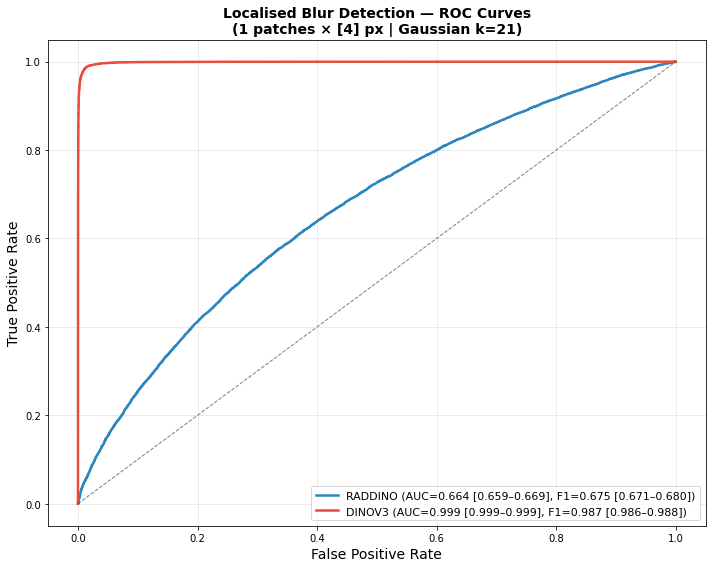

Plot saved: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_4x4/localized_blur_roc_curves.png

RESULTS SUMMARY
Model      | AUC                              | F1                               | Threshold
--------------------------------------------------------------------------------
RADDINO    | 0.6640 [0.6590–0.6691]           | 0.6755  [0.6708–0.6800]          | 0.350
DINOV3     | 0.9989 [0.9988–0.9991]           | 0.9868  [0.9857–0.9879]          | 0.282

✅ COMPLETE! Results saved to: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_4x4


In [1]:
# ============================================================================
# STANDALONE LINEAR PROBING (4×4 Analysis)
# ============================================================================

from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, classification_report
)

# Configuration
WORK_DIR = Path("/home/jupyter-yin10/Image_Analysis")
OUTPUT_DIR = WORK_DIR / "NIH_Localized_Blur_4x4"

train_path = OUTPUT_DIR / "localized_blur_train.parquet"
test_path = OUTPUT_DIR / "localized_blur_test.parquet"

# Parameters (from your original code)
PATCH_SIZES = [4]
NUM_PATCHES = 1
BLUR_KSIZE = 21

print(f"\n{'='*70}")
print("LINEAR PROBING ANALYSIS WITH CONFIDENCE INTERVALS")
print(f"{'='*70}")
print(f"Bootstrap samples: 1000, Confidence level: 95%")

# ============================================================================
# LinearProbingAnalyzer Class (copy from your Cell 5)
# ============================================================================

class LinearProbingAnalyzer:
    """IDENTICAL to your original code."""

    def __init__(self, n_bootstrap=1000, confidence_level=0.95):
        self.results = {}
        self.n_bootstrap = n_bootstrap
        self.confidence_level = confidence_level

    def load_embeddings(self, parquet_path, embedding_col):
        df = pd.read_parquet(parquet_path)
        valid_mask = df[embedding_col].notna()
        df_valid = df[valid_mask].copy()

        embeddings, labels = [], []
        for _, row in df_valid.iterrows():
            emb = row[embedding_col]
            if isinstance(emb, str):
                import ast
                emb = ast.literal_eval(emb)
            if isinstance(emb, list):
                emb = np.array(emb)
            embeddings.append(emb)
            labels.append(row['noise'])

        X = np.vstack(embeddings)
        y = np.array(labels).astype(int)
        return X, y

    def _best_f1_threshold(self, y_true, y_proba):
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
        f1s = (2 * precisions[1:] * recalls[1:]) / (precisions[1:] + recalls[1:] + 1e-12)
        if len(f1s) == 0:
            return 0.5, 0.0
        idx = np.argmax(f1s)
        return float(thresholds[idx]), float(f1s[idx])

    def _bootstrap_metrics(self, y_test, y_test_proba, threshold):
        n_samples = len(y_test)
        auc_scores = []
        f1_scores = []

        for _ in range(self.n_bootstrap):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            y_boot = y_test[indices]
            y_proba_boot = y_test_proba[indices]

            if len(np.unique(y_boot)) > 1:
                auc_scores.append(roc_auc_score(y_boot, y_proba_boot))

            y_pred_boot = (y_proba_boot >= threshold).astype(int)
            f1_scores.append(f1_score(y_boot, y_pred_boot, zero_division=0))

        alpha = 1 - self.confidence_level
        auc_ci = np.percentile(auc_scores, [100*alpha/2, 100*(1-alpha/2)]) if auc_scores else [0, 0]
        f1_ci = np.percentile(f1_scores, [100*alpha/2, 100*(1-alpha/2)])
        return auc_ci, f1_ci

    def train_and_evaluate(self, model_name, X_train, y_train, X_test, y_test):
        print(f"\nTraining {model_name.upper()}...")

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_train_sc, y_train)

        y_test_proba = model.predict_proba(X_test_sc)[:, 1]
        auc_score = roc_auc_score(y_test, y_test_proba)
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)

        best_thr, _ = self._best_f1_threshold(y_test, y_test_proba)
        y_pred = (y_test_proba >= best_thr).astype(int)
        f1 = f1_score(y_test, y_pred)

        print(f"Computing {self.confidence_level*100:.0f}% CI ({self.n_bootstrap} bootstrap samples)...")
        auc_ci, f1_ci = self._bootstrap_metrics(y_test, y_test_proba, best_thr)

        print(f"{model_name.upper()} - AUC: {auc_score:.4f} [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}] "
              f"| F1@{best_thr:.3f}: {f1:.4f} [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")
        print(classification_report(y_test, y_pred, digits=4))

        self.results[model_name] = {
            'auc': auc_score, 'auc_ci': auc_ci,
            'f1': f1, 'f1_ci': f1_ci,
            'threshold': best_thr,
            'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred
        }
        return auc_score, f1

    def plot_roc_curves(self, save_path):
        plt.figure(figsize=(10, 8))
        colors = {'raddino': '#2E86C1', 'dinov3': '#E74C3C'}

        for model_name in ['raddino', 'dinov3']:
            if model_name in self.results:
                r = self.results[model_name]
                auc_ci_str = f"[{r['auc_ci'][0]:.3f}–{r['auc_ci'][1]:.3f}]"
                f1_ci_str = f"[{r['f1_ci'][0]:.3f}–{r['f1_ci'][1]:.3f}]"
                label = (f'{model_name.upper()} '
                         f'(AUC={r["auc"]:.3f} {auc_ci_str}, '
                         f'F1={r["f1"]:.3f} {f1_ci_str})')
                plt.plot(r['fpr'], r['tpr'],
                         color=colors[model_name], linewidth=2.5, label=label)

        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title(
            f'Localised Blur Detection — ROC Curves\n'
            f'({NUM_PATCHES} patches × {PATCH_SIZES} px | Gaussian k={BLUR_KSIZE})',
            fontsize=14, fontweight='bold'
        )
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Plot saved: {save_path}")

# ============================================================================
# Run Linear Probing
# ============================================================================

analyzer = LinearProbingAnalyzer(n_bootstrap=1000, confidence_level=0.95)

print("\nLoading embeddings...")
X_train_rad, y_train_rad = analyzer.load_embeddings(train_path, 'raddino_embedding')
X_test_rad, y_test_rad = analyzer.load_embeddings(test_path, 'raddino_embedding')
X_train_dino, y_train_dino = analyzer.load_embeddings(train_path, 'dinov3_embedding')
X_test_dino, y_test_dino = analyzer.load_embeddings(test_path, 'dinov3_embedding')

print(f"Train samples: {len(X_train_rad)}, Test samples: {len(X_test_rad)}")

analyzer.train_and_evaluate('raddino', X_train_rad, y_train_rad, X_test_rad, y_test_rad)
analyzer.train_and_evaluate('dinov3', X_train_dino, y_train_dino, X_test_dino, y_test_dino)

roc_path = os.path.join(OUTPUT_DIR, 'localized_blur_roc_curves.png')
analyzer.plot_roc_curves(roc_path)

print(f"\n{'='*70}")
print("RESULTS SUMMARY")
print(f"{'='*70}")
print(f"{'Model':<10s} | {'AUC':<32s} | {'F1':<32s} | Threshold")
print(f"{'-'*80}")
for model, metrics in analyzer.results.items():
    auc_str = f"{metrics['auc']:.4f} [{metrics['auc_ci'][0]:.4f}–{metrics['auc_ci'][1]:.4f}]"
    f1_str = f"{metrics['f1']:.4f}  [{metrics['f1_ci'][0]:.4f}–{metrics['f1_ci'][1]:.4f}]"
    print(f"{model.upper():<10s} | {auc_str:<32s} | {f1_str:<32s} | {metrics['threshold']:.3f}")
print(f"{'='*70}")

print(f"\n✅ COMPLETE! Results saved to: {OUTPUT_DIR}")